In [75]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#Download dataset from HuggingFacer
print("Downloading dataset")
dataset = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset", split="train")

#Convert to pandas to easy manipualtion
df = dataset.to_pandas()

print("Dataset load successfullly! Here is a preview of the columns")
display(df.head(3))



Dataset load successfullly! Here is a preview of the columns


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...


In [76]:
import spacy
import re

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def clean_english_text(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    
    # Noise removal e lower casing
    text = re.sub(r'<.*?>', '', text) #Remove html elements
    text = re.sub(r'[^\w\s]', '', text).lower() #Remove special characters and transform into lowercase


    #2 Process the text through spacy
    doc = nlp(text)

    # 3. Lemmatization & Stopword removal (using spaCy's built-in .is_stop)
    # We also check that the lemma isn't just whitespace
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.lemma_.strip()]


    return " ".join(tokens)


def light_clean_response(text):
    if not isinstance(text, str):
        return ""
    
    text = re.sub(r'<.*?>', '', text)
    text = " ".join(text.split())
    return text
df.head(3)


df["instruction"] = df["instruction"].apply(clean_english_text)
df["response"] = df["response"].apply(light_clean_response)
df.head(3)

,flags,instruction,category,intent,response
0,B,question cancel order order number,ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,question cancel oorder order number,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,need help cancel puchase order number,ORDER,cancel_order,I can sense that you're seeking assistance wit...


In [25]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd

#1 Load the model (it will automatically load the weights the first time)
print("Loading MiniLM model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Prepare the text
# We fill any accidental NaNs with an empty string so the model doesn't crash
sentences = df["instruction"].fillna("").tolist()

# 3. Generate the Embeddings (The Heavy Lifting)
print("Generating embeddings...")
embeddings = model.encode(sentences, show_progress_bar=True)

# 4. Save the raw mathematical array (This is your 'X' feature matrix)
# We save this as a NumPy file because it is lightning fast to load later
np.save('instruction_embedding.npy', embeddings)
print(f"Successfully saved {embeddings.shape[0]} embeddings, each with {embeddings.shape[1]} dimensions")

# 5. Save the full dataset keeping the text, labels, and embeddings together
# We use .parquet instead of .csv because CSVs corrupt arrays/lists of numbers
df['embeddings'] = list(embeddings)
df.to_parquet('dataset_with_embeddings.parquet', index=False)
print("Saved full dataset to dataset_with_embeddings.parquet")



Loading MiniLM model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings...


Batches:   0%|          | 0/840 [00:00<?, ?it/s]

Successfully saved 26872 embeddings, each with 384 dimensions
Saved full dataset to dataset_with_embeddings.parquet


In [8]:
df.head(2)

,flags,instruction,category,intent,response,embeddings
0,B,question cancel order order number,ORDER,cancel_order,I've understood you have a question regarding ...,"[-0.06535058, 0.056159362, 0.08872723, 0.02265..."
1,BQZ,question cancel oorder order number,ORDER,cancel_order,I've been informed that you have a question ab...,"[-0.08258182, 0.06630792, 0.0899082, 0.0267727..."


## Training model

We are going to use 2 models to train. Linear Refression sod SVM
The reason we are not going to use a ANN here is because our transformers wich is a neural network already learned from our data already, so since our data has been passed through MiniLM the neural network already did all the heavy lifting.

In [26]:
#Overlap check invoice and get invoice

# Merge the overlapping invoice intents
df['intent'] = df['intent'].replace({'check_invoice': 'get_invoice'})

# Optional: Verify the change worked
print(df['intent'].value_counts().loc[['get_invoice']])

intent
get_invoice    1999
Name: count, dtype: int64


In [52]:
#Training the model with Linear Regression



from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# 1. Prepare X and y
# Assuming 'embeddings' is your X matrix and 'intent' is your y target
X = np.stack(df["embeddings"].values) #Ensure is a 2D numpy arr
y = df['intent'].values

#To avoid PyArrow indexing clash wee need to strip away pandas/pyarrow metadata and force embeeddings columns to pure 2d numpy arr
X = np.array(df["embeddings"].to_list(), dtype=np.float32)
y = np.array(df['intent'].to_list())

print(f"Feature matrix (X) shape: {X.shape}")
print(f"Target vector (y) shape: {y.shape}")
print(f"X Data type: {X.dtype}")

# 2. Train/Test Split (80% for training, 20% for testing)
# stratify=y ensures that the 80/20 split is perfectly balanced across all 26 intents
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y )

print(f"Training on {X_train.shape[0]} samples, testing on {X_test.shape[0]} samples.")

# 3. Initialize and Train the Logistic Regression Model
# We set max_iter=1000 because 384-dimensional embeddings can take a bit longer to converge
print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

#4. Predict on the hidden Test set
y_pred_lr = lr_model.predict(X_test)

#5 Evaluate the Results
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"\n---- Logistic Regression Results ---")
print(f"Overall Accuracy: {accuracy_lr * 100:.2f}%\n")

#Classification Report
print("Detailed Classification Report")
print(classification_report(y_test, y_pred_lr))

Feature matrix (X) shape: (26872, 384)
Target vector (y) shape: (26872,)
X Data type: float32
Training on 21497 samples, testing on 5375 samples.

Training Logistic Regression...

---- Logistic Regression Results ---
Overall Accuracy: 99.53%

Detailed Classification Report
                          precision    recall  f1-score   support

            cancel_order       0.99      0.99      0.99       200
            change_order       0.98      1.00      0.99       199
 change_shipping_address       1.00      0.98      0.99       195
  check_cancellation_fee       1.00      1.00      1.00       190
   check_payment_methods       1.00      1.00      1.00       200
     check_refund_policy       1.00      1.00      1.00       199
               complaint       0.99      0.99      0.99       200
contact_customer_service       1.00      0.99      0.99       200
     contact_human_agent       1.00      1.00      1.00       200
          create_account       0.99      1.00      0.99       199

In [21]:
y_test

array(['payment_issue', 'check_refund_policy', 'check_payment_methods',
       ..., 'contact_customer_service', 'newsletter_subscription',
       'edit_account'], shape=(5375,), dtype='<U24')

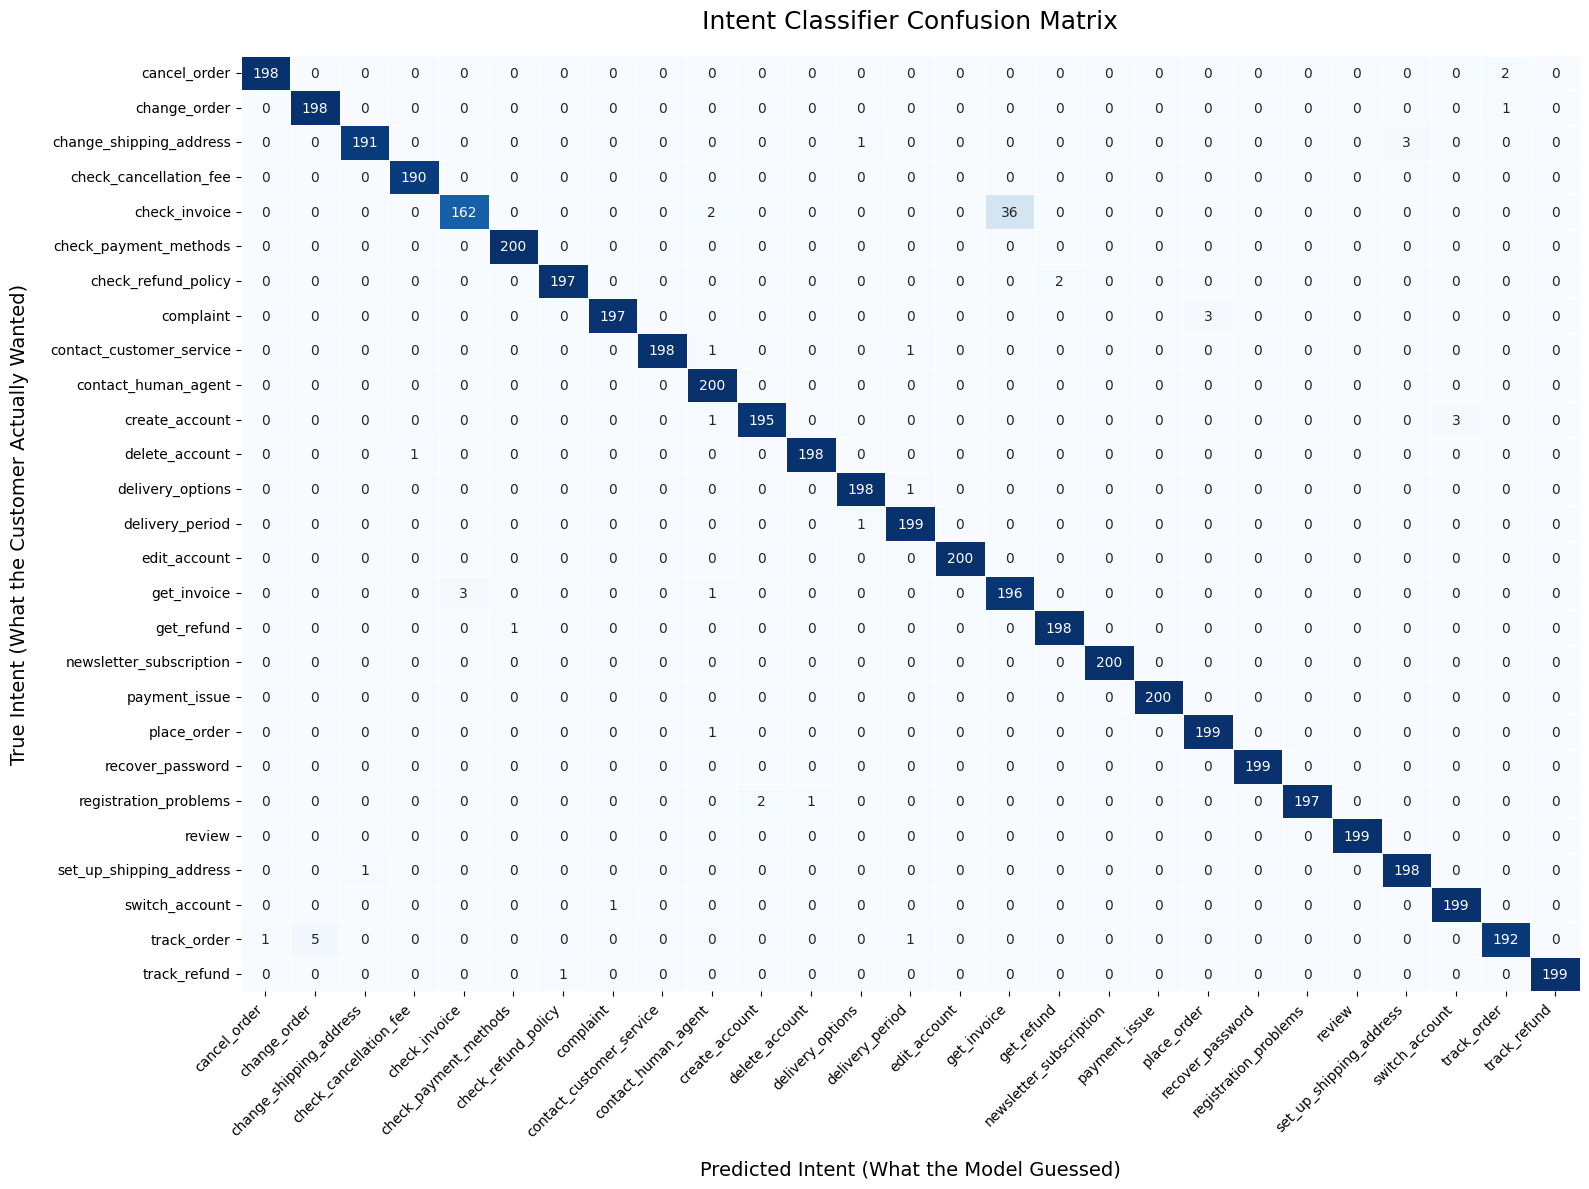

In [23]:
#Our Result are really good but we can see that the check_invoice is distancing from the others results.
#This is probably due to the fact that under INVOIEC category we have 2 intent that can be overlapping meanings they are:
# check_invoice and get_invoice

# First we are going to look into a Confusion Matrix to see their correlation

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the raw confusion matrix numbers
# y_test are the true labels, y_pred_lr are the model's predictions
cm = confusion_matrix(y_test, y_pred_lr, labels=lr_model.classes_)

# 2. Set up a large figure size so the 26 classes don't squish together
plt.figure(figsize=(16,12))

# 3. Create a heatmap using Seaborn
# annot=True puts the numbers in the boxes, fmt='d' ensures they are whole numbers
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lr_model.classes_,
            yticklabels=lr_model.classes_,
            linewidths=.5, cbar=False)

# 4. Add titles and labels
plt.title('Intent Classifier Confusion Matrix', fontsize=18, pad=20)
plt.xlabel('Predicted Intent (What the Model Guessed)', fontsize=14, labelpad=15)
plt.ylabel('True Intent (What the Customer Actually Wanted)', fontsize=14, labelpad=15)

# 5. Rotate the x-axis labels so they are readable
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# 6. Adjust layout and show/save
plt.tight_layout()
plt.savefig('confusion_matrix_logistic_regression.png', dpi=300)
plt.show()


In [ ]:
#As we can see there are a Semantic overlap between get_incoive and check_invoice. In order to fix that we are going to merge the intents
# This will be done at beginnining of the model, but since i want to let this notebook in a order of logic i will doo all over again bellow

In [66]:
# Now we will create a Sentiment model or Conflict detector

# Reason
# We will feed our planner agent, so he behave differently when custoer is angry


#How will be done -> Opt 1 separate sentiments based on flags eg fag W means a angry customer, but the flags can stack so we can have something like ABC, WEDF, etc wich means that categorize
# this into classes only by separating by flag its difficult since we have 17 flags that can be combined to form different sentiments Resulting in a not good definition

# 2 Option and the one chosen for this project
# We will feed the user question to a LLM and based on the LLM response we will label the sentiment for the user. Since we have almost 30 k samples and feed this quantity of data
#to a LLM its a little expensive for our model, we are going to stratify our data and pick 2000 random samples, this should be enough to our model to have a good predict

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#Download dataset from HuggingFacer
print("Downloading dataset")
dataset = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset", split="train")

#Convert to pandas to easy manipualtion
df_sentiment = dataset.to_pandas()



In [80]:
print(df["instruction"].str.len().mean())

print(df_sentiment["instruction"].str.len().mean())

29.38508484668056
46.88951324799047


In [82]:
print(df_sample["instruction"].str.len().mean())

47.08125


In [37]:
from openai import OpenAI
from dotenv import load_dotenv
import os
load_dotenv(override=True)

api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    print("No API key was found - please head over to the troubleshooting notebook in this folder to identify & fix!")
else:
    print("API key found and looks good so far!")


API key found and looks good so far!


In [ ]:
from tqdm import tqdm
from openai import OpenAI
from dotenv import load_dotenv
#Setup the API client
client = OpenAI()

def get_sentiment_label(text):
    """Passes a single instruction to the LLM and returns the strict category."""

    system_prompt = """ 
    You are an expert customer support sentiment classifier.
    Read the customer message and classify their emotional state into exactly ONE of these four categories:
    - Frustraded
    - Urgent
    - Polite
    - Neutral

    Output NOTHING but the exact category word. No ponctuation, no explanation.
    """

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            temperature=0.0,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"Customer message: '{text}'"}
            ]
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f"API Error: {e}")
        return "Error"
    


In [40]:
# Step 1 stratify dataset
import time
SAMPLES_PER_INTENT = 80 
df_sample = df.groupby('intent').apply(lambda x: x.sample(SAMPLES_PER_INTENT, random_state=42)).reset_index(drop=True)

print(f"Create a sample of{len(df_sample)} rows for LLM labeling.")


print("Starting LLM labeling process...")
sentiment_labels = []

for text in tqdm(df_sample['instruction']): #Since now the object is detect the sentiment from the User we will keep the original input
    label = get_sentiment_label(text)
    sentiment_labels.append(label)

    time.sleep(0.1)

df_sample['sentiment'] = sentiment_labels

#Save the golden dataset (so we dont need to pay the API again)
df_sample.to_csv('llm_labeled_sentiment_data.csv', index=False)
print("\nSuccess! Dataset saved as llm_labeled_sentiment_data.csv")



Create a sample of2080 rows for LLM labeling.
Starting LLM labeling process...


100%|██████████| 2080/2080 [20:57<00:00,  1.65it/s]



Success! Dataset saved as llm_labeled_sentiment_data.csv


In [81]:
#df_sample["sentiment"] = df_sample["sentiment"].replace({'Frustraded': 'Frustrated'})
df_sample["sentiment"].value_counts()

sentiment
Urgent        922
Neutral       445
Polite        438
Frustrated    275
Name: count, dtype: int64

In [83]:
from sentence_transformers import SentenceTransformer
import numpy as np

# 1. Load the model again (it's already cached, so it's instant)
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Generate embeddings using the RAW instruction column this time!
print("Generating 'Emotional' embeddings from raw text...")
raw_sentences = df_sample['instruction'].fillna("").tolist()
raw_embeddings = model.encode(raw_sentences, show_progress_bar=True)

# 3. Set up your new X and y
X_sentiment_raw = np.array(raw_embeddings, dtype=np.float32)
y_sentiment = np.array(df_sample['sentiment'].tolist())

#X_sample = np.stack(df_sample["embeddings"].values) #Ensure is a 2D numpy arr
#y_sample = df_sample['sentiment'].values

#To avoid PyArrow indexing clash wee need to strip away pandas/pyarrow metadata and force embeeddings columns to pure 2d numpy arr
#X_sample = np.array(df_sample["embeddings"].to_list(), dtype=np.float32)
#y_sample = np.array(df_sample['sentiment'].to_list())

print(f"Feature matrix (X) shape: {X_sentiment_raw.shape}")
print(f"Target vector (y) shape: {y_sentiment.shape}")
print(f"X Data type: {X_sentiment_raw.dtype}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating 'Emotional' embeddings from raw text...


Batches:   0%|          | 0/65 [00:00<?, ?it/s]

Feature matrix (X) shape: (2080, 384)
Target vector (y) shape: (2080,)
X Data type: float32


In [85]:
#X_train_sentiment, X_test_sentiment, y_train_sentiment, y_test_sentiment = train_test_split(X_sample,y_sample,test_size=0.2, random_state=42, stratify=y_sample)

# 4. Train/Test Split (using the same random state so it's a fair comparison)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sentiment_raw, y_sentiment, test_size=0.2, random_state=42, stratify=y_sentiment
)
# 3. Initialize and Train the Logistic Regression Model
# We set max_iter=1000 because 384-dimensional embeddings can take a bit longer to converge
print("\nTraining Logistic Regression...")
lr_model_sentiment = LogisticRegression(max_iter=1000, class_weight=
                                        'balanced', random_state=42)
lr_model_sentiment.fit(X_train_s, y_train_s)

#4. Predict on the hidden Test set
y_pred_lr_sentiment = lr_model_sentiment.predict(X_test_s)

#5 Evaluate the Results
accuracy_lr_sentiment = accuracy_score(y_test_s, y_pred_lr_sentiment)
print(f"\n---- Logistic Regression Results ---")
print(f"Overall Accuracy: {accuracy_lr_sentiment * 100:.2f}%\n")

#Classification Report
print("Detailed Classification Report")
print(classification_report(y_test_s, y_pred_lr_sentiment))




Training Logistic Regression...

---- Logistic Regression Results ---
Overall Accuracy: 66.35%

Detailed Classification Report
              precision    recall  f1-score   support

  Frustrated       0.58      0.78      0.67        55
     Neutral       0.64      0.67      0.66        89
      Polite       0.55      0.61      0.58        88
      Urgent       0.79      0.65      0.71       184

    accuracy                           0.66       416
   macro avg       0.64      0.68      0.65       416
weighted avg       0.68      0.66      0.67       416



## 🧠 Sentiment Classifier: Performance & Architectural Justification
While the Intent Classifier achieves near-perfect accuracy (99.5%), the Sentiment Classifier operates at a ~66% overall accuracy. In the context of our production architecture, this is considered a highly successful baseline. Here is the data science and business rationale behind this metric.

1. The Subjectivity of Human Emotion
Unlike intent prediction (which is highly objective and keyword-driven, e.g., "cancel" = cancel_order), sentiment analysis is inherently subjective.

The target labels (Frustrated, Neutral, Polite, Urgent) were distilled using a Zero-Shot LLM (gpt-4o-mini).

In a 4-class subjective problem, a random guess yields 25% accuracy. Achieving ~66% using a blazing-fast, lightweight Logistic Regression model running on all-MiniLM-L6-v2 embeddings proves the model is capturing deep emotional semantics without the latency of a heavy neural network.

2. Overcoming Target Leakage and LLM Bias
During the data labeling phase, the LLM exhibited a known bias: it aggressively categorized customer support tickets as Urgent (accounting for nearly 50% of the dataset).
Initially, the Logistic Regression model exploited this imbalance, resulting in a slightly higher overall accuracy, but a poor Recall for critical minority classes:

Initial 'Frustrated' Recall: 0.51 (The system was missing half of the angry customers).

3. Strategic Tradeoff: Recall > Overall Accuracy
In a customer support pipeline, missing a frustrated customer is a critical business failure that leads to churn. To fix this, we applied class_weight='balanced' to the Logistic Regression model.

The Final Results:

Overall Accuracy stabilized at 66.35%.

'Frustrated' Recall skyrocketed to 0.78. * 'Polite' Recall improved to 0.61.

The model stopped lazily predicting 'Urgent' as a default fallback.

By deliberately sacrificing a marginal amount of overall precision, we built a much fairer, highly sensitive "EQ Brain" for the system. When the Planner node receives a Frustrated flag, it can now confidently instruct the downstream LLM Agent to prioritize empathy and de-escalation.

In [61]:
import joblib

# 1. Save the 99.5% Intent Classifier
joblib.dump(lr_model, 'intent_classifier_model.pkl')
print("Saved Intent Model -> intent_classifier_model.pkl")

# 2. Save the Balanced Sentiment Classifier
joblib.dump(lr_model_sentiment, 'sentiment_classifier_model.pkl')
print("Saved Sentiment Model -> sentiment_classifier_model.pkl")

# Note: You don't need to save the MiniLM model; the Hugging Face library 
# caches it automatically on your machine!

Saved Intent Model -> intent_classifier_model.pkl
Saved Sentiment Model -> sentiment_classifier_model.pkl


The average message length is: 398 characters



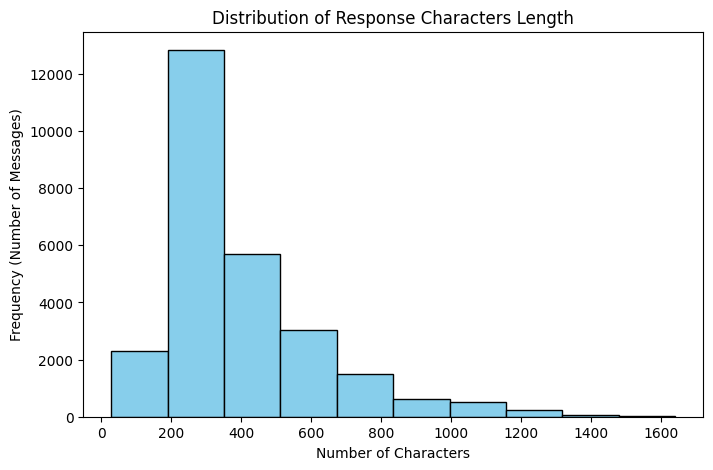

In [7]:
mean_length = df["response"].str.len().mean()
print(f"The average message length is: {int(mean_length)} characters\n")

df["response"].str.len().plot(
    kind='hist',
    bins=10,
    edgecolor='black',
    color='skyblue',
    figsize=(8,5)
)

plt.title("Distribution of Response Characters Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency (Number of Messages)")
plt.show()

In [ ]:
#Text Vectorization (The translation Phase)

from sentence_transformers import SentenceTrnasformer

model = SentenceTrnasformer('all-MiniLM-L6-v2')

#Transform the clean text column into numerical vectors
embeddings = df.map( lambda x: model.encode(x))

,flags,instruction,category,intent,response
0,b,question about cancelling order {{order number}},order,cancel_order,i've understood you have a question regarding ...
1,bqz,i have a question about cancelling oorder {{or...,order,cancel_order,i've been informed that you have a question ab...
2,blqz,i need help cancelling puchase {{order number}},order,cancel_order,i can sense that you're seeking assistance wit...


In [10]:
#Noise Removal
import re
def clean_noise(txt):
    if not isinstance(txt, str):
        return txt
    #Remove tags HTML
    txt = re.sub(r'<.*?>', '', txt)
    # Rremove poncuation and special characters
    txt = re.sub(r'[^\w\s]', '', txt)
    # Norlalize spaces extras and conver in lowercase
    txt = " ".join(txt.split()).lower()
    
    return txt

df = df.map(lambda x: clean_noise(x) if isinstance(x, str) else x)

df.head(3)

,flags,instruction,category,intent,response
0,b,question about cancelling order order number,order,cancel_order,ive understood you have a question regarding c...
1,bqz,i have a question about cancelling oorder orde...,order,cancel_order,ive been informed that you have a question abo...
2,blqz,i need help cancelling puchase order number,order,cancel_order,i can sense that youre seeking assistance with...


In [ ]:
#Stop words removal (ex the, and, is, ot, at)
import nltk
from nltk.corpus import stopwords

#Download stopwords package
nltk.download("stopwords")


stop_words = set(stopwords.words('english'))



def clean_full(text):
    if not isinstance(text, str):
        return text
    
    words = text.split()
    words_filtered = [w for w in words if w in stop_words]

    return " ".join(words_filtered)

In [ ]:
#Lemmatization technique refunding, refunded, refunds all to just refund
import spacy
#Download english models
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def clean_english_text(text):
    if not isinstance(text, str):
        return text
    
    # 1. Lowercase & Noise Removal (HTML, Especial Characters)
    text = re.sub(r'<.*?>', '', text) # HTML
    text = re.sub(r'[^\w\s]', '', text).lower() # Specials & Lower

    doc = nlp(text)

    tokens  = [token for token in doc if token.text not in stop_words]

    return " ".join(tokens)

df = df.map(lambda x: clean_english_text(x) if isinstance(x, str) else x)


df.head(3)